# Tutorial: Field-of-View tools

This tutorial covers a small family of helpers in `bolides.fov_utils` for working
with the **fields of view (FOVs) of the GLM instruments aboard the GOES
satellites** (GOES-16, -17, -18 and -19).

Unlike most of `bolides`, these tools **do not require a
[`BolideDataFrame`](tutorial_BolideDataFrame.ipynb)** — they answer questions
about the satellites and their FOVs directly, so other code can import and call
them without first loading any bolide data. They read only data packaged with
`bolides`, so they also work fully offline.

Three functions are covered (see the **Boundary API** reference page for full
signatures):

| function | question it answers |
|---|---|
| `get_satellites` | *Which GOES satellites' GLM could observe this point in space and time?* |
| `get_obs_intervals` | *When was a given satellite operational, and in which FOV orientation?* |
| `get_boundary` | *What is the actual FOV polygon for a given sensor/position?* |

If instead you want to *filter a whole table* of detections by what a sensor
could observe, see `BolideDataFrame.filter_observation` /
`filter_boundary` in the
[BolideDataFrame tutorial](tutorial_BolideDataFrame.ipynb); those methods are
built on the same data as the tools below.

In [1]:
%matplotlib inline
from bolides import get_satellites
from bolides.fov_utils import get_boundary, get_obs_intervals

## `get_satellites`: which satellites can observe a point?

Given a point in space (latitude, longitude) and time, `get_satellites` returns
the GOES satellites whose GLM was both **operational** and had the point **within
its field of view** at that time.

Let's start with a single spatiotemporal point.

In [2]:
get_satellites(lat=27.11355, lon=-94.086853, time="2024-09-11 06:24:52.608")

,satellite,position,boundary,inverted,start,end
0,16,east,goes-e,False,2017-12-18 00:00:00+00:00,2025-04-06 00:00:00+00:00
1,18,west,goes-w-ni,False,2023-01-04 00:00:00+00:00,NaT


By default the result is a `DataFrame` with one row per observing satellite:

- `satellite` — the GOES satellite number,
- `position` — `'east'` or `'west'` (the GOES position it occupied),
- `boundary` — the FOV boundary name in effect (see `get_boundary` below),
- `inverted` — whether the GLM was in its yaw-flipped orientation (only relevant
  for GOES-17),
- `start` / `end` — the operational window that matched.

If you only need the satellite numbers, pass `numbers_only=True`:

In [3]:
get_satellites(27.11355, -94.086853, "2024-09-11 06:24:52.608", numbers_only=True)

[16, 18]

### Operational handoffs are handled automatically

GOES satellites are retired and replaced over time:

- **GOES-East**: GOES-16 → GOES-19 (April 2025)
- **GOES-West**: GOES-17 → GOES-18 (January 2023)

Because `get_satellites` checks each satellite's operational window, the *same
point* returns different satellites depending on *when* it occurred:

In [4]:
for t in ["2019-06-01", "2022-06-01", "2024-06-01", "2025-06-01"]:
    print(t, "->", get_satellites(27.11355, -94.086853, t, numbers_only=True))

2019-06-01 -> [16, 17]
2022-06-01 -> [16, 17]
2024-06-01 -> [16, 18]


2025-06-01 -> [18, 19]


### Many points at once

`lat`, `lon` and `time` also accept equal-length lists/arrays. With
`numbers_only=True` you get one list per point; otherwise the `DataFrame` gains a
`point` column indexing back into your inputs.

In [5]:
lats  = [27.11355, 27.11355, 51.0]
lons  = [-94.086853, -94.086853, 10.0]
times = ["2024-06-01", "2025-06-01", "2024-06-01"]

print(get_satellites(lats, lons, times, numbers_only=True))

[[16, 18], [18, 19], []]


In [6]:
get_satellites(lats, lons, times)

,point,satellite,position,boundary,inverted,start,end
0,0,16,east,goes-e,False,2017-12-18 00:00:00+00:00,2025-04-06 00:00:00+00:00
1,0,18,west,goes-w-ni,False,2023-01-04 00:00:00+00:00,NaT
2,1,18,west,goes-w-ni,False,2023-01-04 00:00:00+00:00,NaT
3,1,19,east,goes-e,False,2025-04-07 00:00:00+00:00,NaT


A point outside every FOV (here, the Indian Ocean) simply returns no
satellites — an empty list, or an empty `DataFrame`.

In [7]:
print(get_satellites(-20.0, 80.0, "2024-09-11", numbers_only=True))
get_satellites(-20.0, 80.0, "2024-09-11")

[]


,satellite,position,boundary,inverted,start,end


## `get_obs_intervals`: when was a satellite operational?

`get_satellites` decides observability using small packaged tables of each
satellite's operational windows and FOV orientations. You can read those tables
directly with `get_obs_intervals`.

GOES-17 is the interesting one: it underwent biannual **yaw flips**, alternating
between a non-inverted (`goes-w-ni`) and inverted (`goes-w-i`) FOV.

In [8]:
get_obs_intervals(17)

,boundary,start,end,note
0,goes-17-89.5,2018-05-08,2018-10-24,check
1,goes-w-i,2018-11-13,2019-03-27,check
2,goes-w-ni,2019-03-28,2019-09-09 21:00:00,check
3,goes-w-i,2019-09-09 21:00:00,2020-04-06 21:45:00,known
4,goes-w-ni,2020-04-06 21:45:00,2020-09-08 21:45:00,known
5,goes-w-i,2020-09-08 21:45:00,2021-04-06 21:00:00,known
6,goes-w-ni,2021-04-06 21:00:00,2021-09-07 21:00:00,known
7,goes-w-i,2021-09-07 21:00:00,2022-04-05 21:00:00,known
8,goes-w-ni,2022-04-05 21:00:00,2023-01-03,known


The other satellites have simpler histories. The satellite can be given as an
int or in any of the common string forms (`16`, `'g16'`, `'glm-16'`,
`'goes-16'`).

In [9]:
get_obs_intervals('goes-16')

,boundary,start,end
0,goes-e,2017-12-18,2025-04-06


## `get_boundary`: the FOV polygons

`get_boundary` returns the actual field-of-view polygon for a sensor or GOES
position as a `shapely` geometry. Valid names include `'goes-e'`, `'goes-w'`,
`'goes-w-ni'`, `'goes-w-i'`, `'goes'` (the combined GOES FOV), the Fengyun-4A
`'fy4a*'` FOVs, and the Global Meteor Network `'gmn-*km'` FOVs — see the
`get_boundary` reference for the full list.

In [10]:
boundary = get_boundary('goes-e')
print(type(boundary).__name__, "| geometry type:", boundary.geom_type)

Polygon | geometry type: Polygon


By default polygons are returned in an Azimuthal Equidistant CRS (centered on
the north pole), which is convenient for area/contains computations. Pass
`crs='epsg:4326'` to get them back in longitude/latitude instead.

To draw FOVs on a map, the package provides `fov_utils.add_boundary`, which adds
a boundary to a Cartopy `GeoAxes` (handling the projection for you). Here we plot
the GOES-East and GOES-West FOVs together with the example point from earlier —
note it falls inside *both*, matching the `get_satellites` result above.

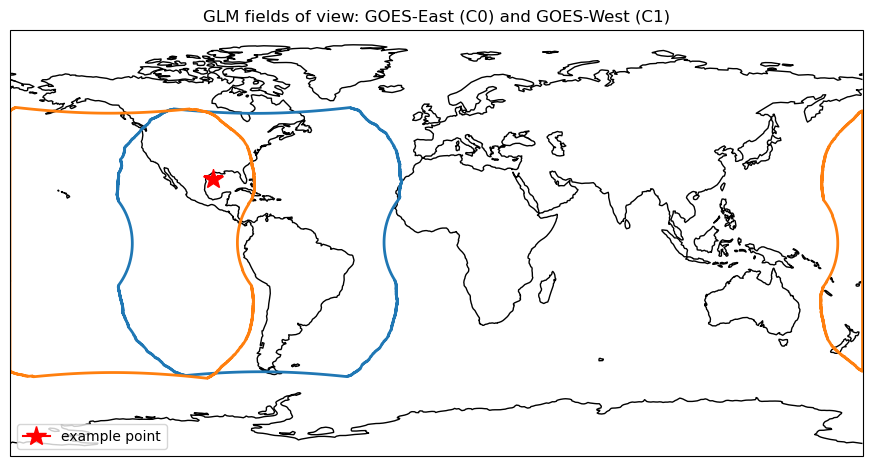

In [11]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from bolides.fov_utils import add_boundary

fig = plt.figure(figsize=(11, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.set_global()

add_boundary(ax, 'goes-e', boundary_style={'edgecolor': 'C0', 'linewidth': 2, 'facecolor': 'none'})
add_boundary(ax, 'goes-w', boundary_style={'edgecolor': 'C1', 'linewidth': 2, 'facecolor': 'none'})
ax.plot(-94.086853, 27.11355, marker='*', color='red', markersize=15,
        transform=ccrs.PlateCarree(), label='example point')

ax.legend(loc='lower left')
ax.set_title('GLM fields of view: GOES-East (C0) and GOES-West (C1)')
plt.show()

## Summary

- `get_satellites` — which GOES satellites' GLM could observe a spatiotemporal
  point (single or vectorized; numbers or structured info).
- `get_obs_intervals` — each satellite's operational windows and FOV
  orientations.
- `get_boundary` — the FOV polygons themselves, with `fov_utils.add_boundary`
  for plotting.

None of these require a `BolideDataFrame`. To filter a table of detections by
observability instead, see `BolideDataFrame.filter_observation` in the
[BolideDataFrame tutorial](tutorial_BolideDataFrame.ipynb).